# Rebalancing Strategy Analysis

In this notebook, we compare different portfolio rebalancing strategies.

The analysis compares:

- Buy & Hold
- Monthly Rebalancing
- Quarterly Rebalancing
- Annual Rebalancing

The objective is to understand how rebalancing frequency affects portfolio performance, volatility, Sharpe Ratio, and maximum drawdown.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project folders
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
IMAGES_DIR = PROJECT_ROOT / "images"

OUTPUTS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

# Load daily returns
returns = pd.read_csv(
    DATA_DIR / "daily_returns.csv",
    index_col=0,
    parse_dates=True
)

returns.head()

,GLD,QQQ,SPY,TLT
Date,,,,
2018-01-03,-0.002637,0.009717,0.006325,0.004782
2018-01-04,0.005127,0.001749,0.004215,-0.000159
2018-01-05,-0.001036,0.010043,0.006664,-0.002856
2018-01-08,-0.000160,0.003891,0.001829,-0.000637
2018-01-09,-0.004628,0.000062,0.002264,-0.013372


In [3]:
# Portfolio allocations
portfolios = {
    "Conservative": {
        "SPY": 0.20,
        "QQQ": 0.10,
        "TLT": 0.50,
        "GLD": 0.20
    },
    "Balanced": {
        "SPY": 0.40,
        "QQQ": 0.30,
        "TLT": 0.20,
        "GLD": 0.10
    },
    "Aggressive": {
        "SPY": 0.50,
        "QQQ": 0.40,
        "TLT": 0.05,
        "GLD": 0.05
    }
}

assets = returns.columns
initial_portfolio_value = 10_000
trading_days = 252
risk_free_rate = 0.00

portfolios

{'Conservative': {'SPY': 0.2, 'QQQ': 0.1, 'TLT': 0.5, 'GLD': 0.2},
 'Balanced': {'SPY': 0.4, 'QQQ': 0.3, 'TLT': 0.2, 'GLD': 0.1},
 'Aggressive': {'SPY': 0.5, 'QQQ': 0.4, 'TLT': 0.05, 'GLD': 0.05}}

In [4]:
def get_rebalance_dates(returns_index, frequency):
    """
    Returns the last available trading day for each rebalancing period.
    
    frequency can be:
    - "M" for monthly
    - "Q" for quarterly
    - "Y" for annual
    """
    return returns_index.to_series().groupby(
        returns_index.to_period(frequency)
    ).tail(1).index


def simulate_rebalanced_portfolio(
    returns,
    weights_dict,
    initial_value=10_000,
    rebalance_frequency=None
):
    """
    Simulates portfolio value over time.

    If rebalance_frequency is None, the strategy is Buy & Hold.
    Otherwise, the portfolio is rebalanced at the selected frequency.
    """
    weights = pd.Series(weights_dict)
    weights = weights[returns.columns]

    asset_values = weights * initial_value
    portfolio_values = []

    if rebalance_frequency is not None:
        rebalance_dates = get_rebalance_dates(returns.index, rebalance_frequency)
    else:
        rebalance_dates = []

    for date, daily_return in returns.iterrows():
        asset_values = asset_values * (1 + daily_return)

        total_value = asset_values.sum()
        portfolio_values.append(total_value)

        if date in rebalance_dates:
            asset_values = weights * total_value

    portfolio_values = pd.Series(
        portfolio_values,
        index=returns.index,
        name="Portfolio Value"
    )

    return portfolio_values

In [5]:
test_values = simulate_rebalanced_portfolio(
    returns=returns,
    weights_dict=portfolios["Balanced"],
    initial_value=initial_portfolio_value,
    rebalance_frequency="M"
)

test_values.tail()

Date
2026-06-30    28991.199037
2026-07-01    28821.159114
2026-07-02    28716.068659
2026-07-06    28965.150183
2026-07-07    28654.443867
Name: Portfolio Value, dtype: float64

In [6]:
rebalancing_strategies = {
    "Buy & Hold": None,
    "Monthly Rebalancing": "M",
    "Quarterly Rebalancing": "Q",
    "Annual Rebalancing": "Y"
}

all_strategy_values = {}

for portfolio_name, allocation in portfolios.items():
    all_strategy_values[portfolio_name] = {}

    for strategy_name, frequency in rebalancing_strategies.items():
        values = simulate_rebalanced_portfolio(
            returns=returns,
            weights_dict=allocation,
            initial_value=initial_portfolio_value,
            rebalance_frequency=frequency
        )

        all_strategy_values[portfolio_name][strategy_name] = values

print("Rebalancing simulations completed.")

Rebalancing simulations completed.


In [7]:
def calculate_performance_metrics(portfolio_values, risk_free_rate=0.00):
    """
    Calculates performance and risk metrics for a portfolio value series.
    """
    daily_returns = portfolio_values.pct_change().dropna()

    final_value = portfolio_values.iloc[-1]
    total_return = final_value / portfolio_values.iloc[0] - 1

    annualized_return = (final_value / portfolio_values.iloc[0]) ** (
        trading_days / len(daily_returns)
    ) - 1

    annualized_volatility = daily_returns.std() * np.sqrt(trading_days)

    sharpe_ratio = (
        (annualized_return - risk_free_rate) / annualized_volatility
        if annualized_volatility != 0
        else np.nan
    )

    running_max = portfolio_values.cummax()
    drawdown = portfolio_values / running_max - 1
    max_drawdown = drawdown.min()

    return {
        "Final Value": final_value,
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": max_drawdown
    }

In [8]:
rebalancing_results = []

for portfolio_name, strategies in all_strategy_values.items():
    for strategy_name, values in strategies.items():
        metrics = calculate_performance_metrics(
            values,
            risk_free_rate=risk_free_rate
        )

        metrics["Portfolio"] = portfolio_name
        metrics["Strategy"] = strategy_name

        rebalancing_results.append(metrics)

rebalancing_summary = pd.DataFrame(rebalancing_results)

# Reorder columns
rebalancing_summary = rebalancing_summary[
    [
        "Portfolio",
        "Strategy",
        "Final Value",
        "Total Return",
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ]
]

# Save results
rebalancing_summary.to_csv(
    OUTPUTS_DIR / "rebalancing_strategy_summary.csv",
    index=False
)

rebalancing_summary

,Portfolio,Strategy,Final Value,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
0,Conservative,Buy & Hold,21379.995969,1.129269,0.093261,0.112580,0.828399,-0.274633
1,Conservative,Monthly Rebalancing,17894.404954,0.782134,0.070546,0.106583,0.661887,-0.278100
2,Conservative,Quarterly Rebalancing,18144.694427,0.807060,0.072302,0.106894,0.676388,-0.278773
3,Conservative,Annual Rebalancing,18112.147596,0.803819,0.072075,0.106032,0.679741,-0.276295
4,Balanced,Buy & Hold,31587.760538,2.139506,0.144507,0.160650,0.899516,-0.287108
5,Balanced,Monthly Rebalancing,28654.443867,1.847964,0.131423,0.148110,0.887330,-0.277830
6,Balanced,Quarterly Rebalancing,29129.638205,1.895194,0.133620,0.147169,0.907934,-0.278688
7,Balanced,Annual Rebalancing,28855.616290,1.867959,0.132357,0.146615,0.902751,-0.277894
8,Aggressive,Buy & Hold,36691.642822,2.643092,0.164772,0.194804,0.845835,-0.293284
9,Aggressive,Monthly Rebalancing,35568.446398,2.531571,0.160507,0.188272,0.852531,-0.283641


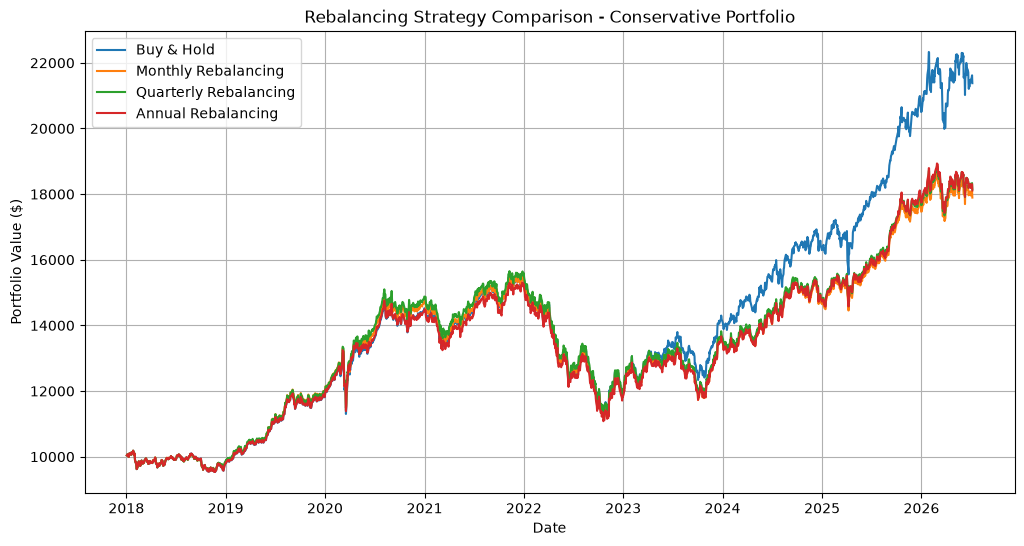

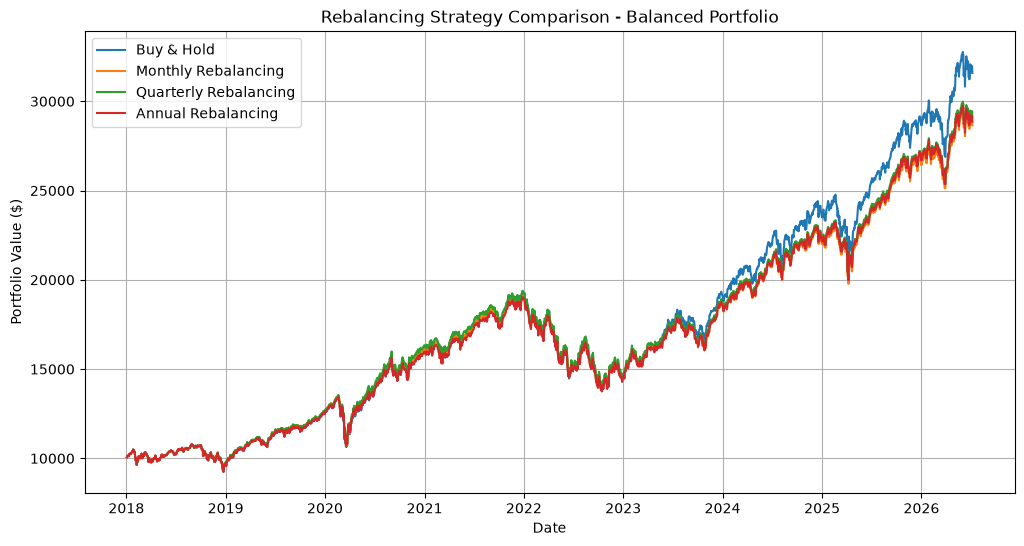

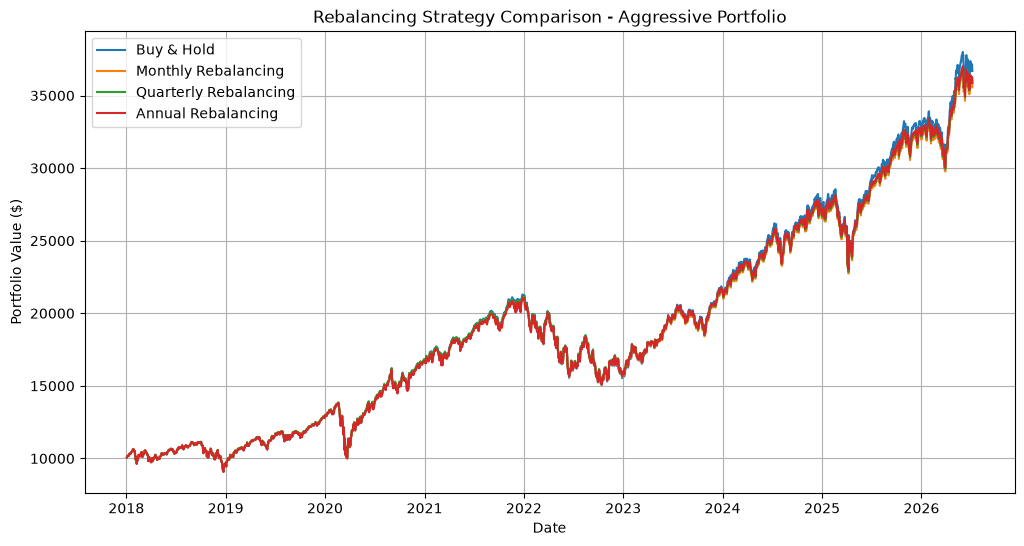

In [9]:
for portfolio_name, strategies in all_strategy_values.items():
    plt.figure(figsize=(12, 6))

    for strategy_name, values in strategies.items():
        plt.plot(values.index, values, label=strategy_name)

    plt.title(f"Rebalancing Strategy Comparison - {portfolio_name} Portfolio")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value ($)")
    plt.legend()
    plt.grid(True)

    filename = f"rebalancing_comparison_{portfolio_name.lower()}.png"
    plt.savefig(IMAGES_DIR / filename, dpi=300, bbox_inches="tight")

    plt.show()

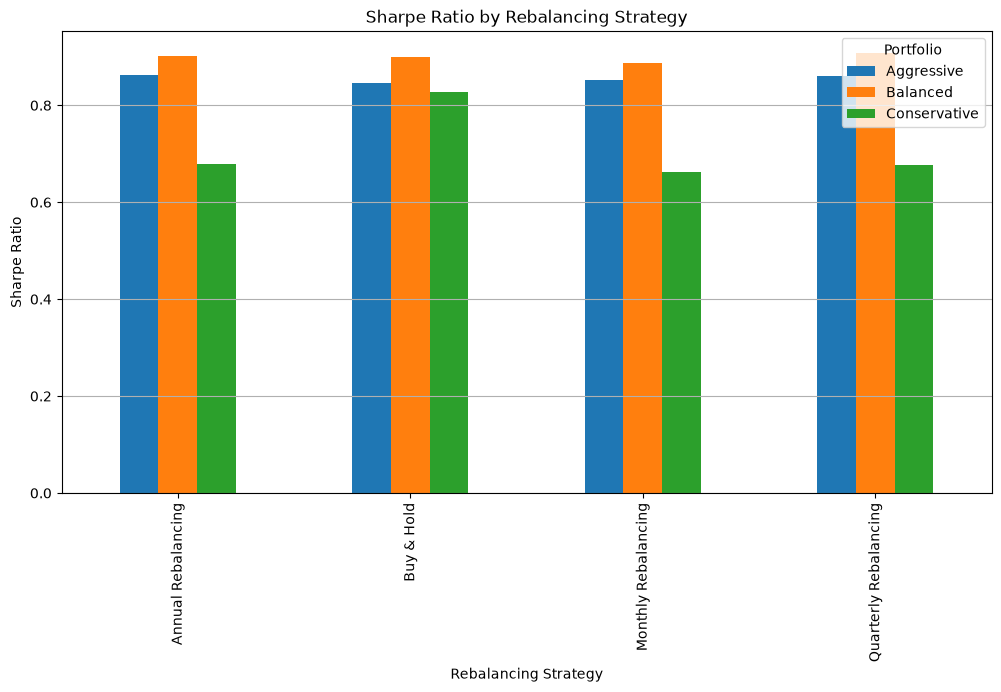

In [10]:
sharpe_pivot = rebalancing_summary.pivot(
    index="Strategy",
    columns="Portfolio",
    values="Sharpe Ratio"
)

ax = sharpe_pivot.plot(kind="bar", figsize=(12, 6))

plt.title("Sharpe Ratio by Rebalancing Strategy")
plt.xlabel("Rebalancing Strategy")
plt.ylabel("Sharpe Ratio")
plt.grid(axis="y")
plt.legend(title="Portfolio")

fig = ax.get_figure()
fig.savefig(IMAGES_DIR / "rebalancing_sharpe_ratio_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

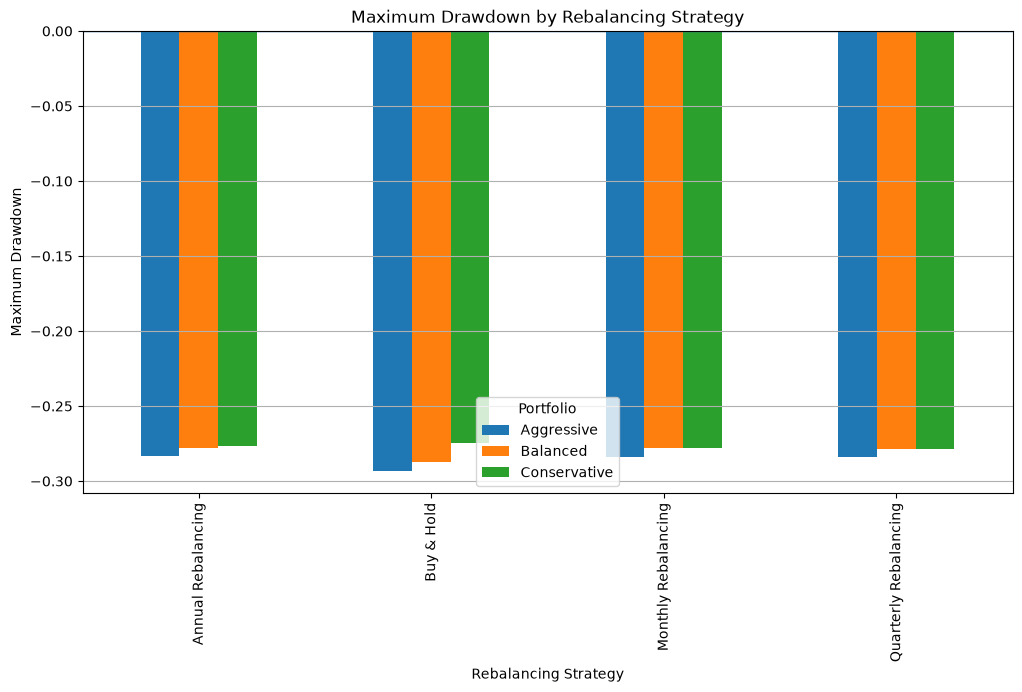

In [11]:
drawdown_pivot = rebalancing_summary.pivot(
    index="Strategy",
    columns="Portfolio",
    values="Maximum Drawdown"
)

ax = drawdown_pivot.plot(kind="bar", figsize=(12, 6))

plt.title("Maximum Drawdown by Rebalancing Strategy")
plt.xlabel("Rebalancing Strategy")
plt.ylabel("Maximum Drawdown")
plt.axhline(0, linewidth=1)
plt.grid(axis="y")
plt.legend(title="Portfolio")

fig = ax.get_figure()
fig.savefig(IMAGES_DIR / "rebalancing_max_drawdown_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

## Rebalancing Strategy Interpretation

The rebalancing analysis compares how different rebalancing frequencies affect portfolio performance and risk.

Buy & Hold allows asset weights to drift over time as some assets outperform others. This can increase exposure to strong-performing assets, but it may also increase concentration risk.

Monthly, quarterly, and annual rebalancing bring the portfolio back to its target allocation at regular intervals. This helps control risk and maintain diversification, but it may reduce upside if the strongest-performing assets are repeatedly trimmed.

The best rebalancing strategy depends on the investor's objectives. More frequent rebalancing can improve risk control, while less frequent rebalancing may allow winners to run for longer.

Overall, this analysis shows that portfolio management is not only about choosing asset weights, but also about deciding how often those weights should be maintained.